# Credit Card Fraud Detection — ML Research Notebook

This notebook covers the complete ML research phase of a real-time fraud detection system.
The goal is to build, evaluate, and export a production-ready classification model that can
identify fraudulent credit card transactions with high recall and acceptable precision.

**Dataset:** ULB Credit Card Fraud Dataset (284,807 transactions, 492 frauds — 0.17% fraud rate)  
**Features:** V1–V28 are PCA-transformed anonymized features. `Time`, `Amount`, and `Class` are the only raw columns.  
**Target:** `Class` — 0 = Legitimate, 1 = Fraud

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'../data/creditcard.csv')

## 1. Exploratory Data Analysis

We begin by understanding the dataset's structure, checking for missing values,
and examining the distribution of key columns — especially the target variable `Class`
and the raw features `Time` and `Amount`.

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isna().sum().sum()

np.int64(0)

In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
df['Class'].describe()

count    284807.000000
mean          0.001727
std           0.041527
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Class, dtype: float64

<Axes: xlabel='Class', ylabel='count'>

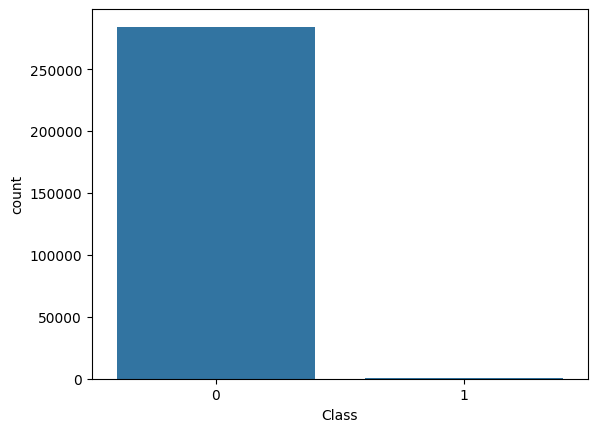

In [9]:
sns.countplot(x = df['Class'])

### EDA

<Axes: xlabel='V1', ylabel='Count'>

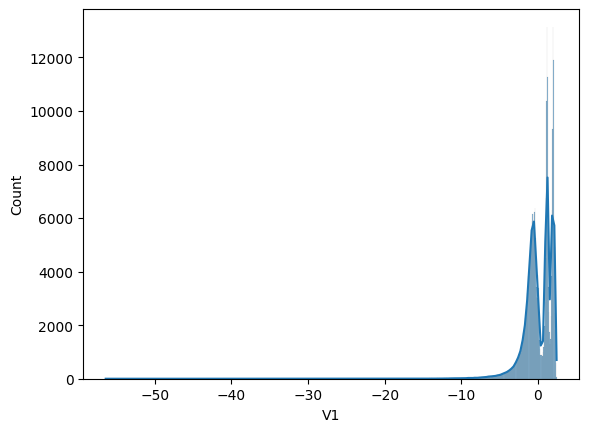

In [10]:
sns.histplot(df['V1'], kde = True)

<Axes: xlabel='V2', ylabel='Count'>

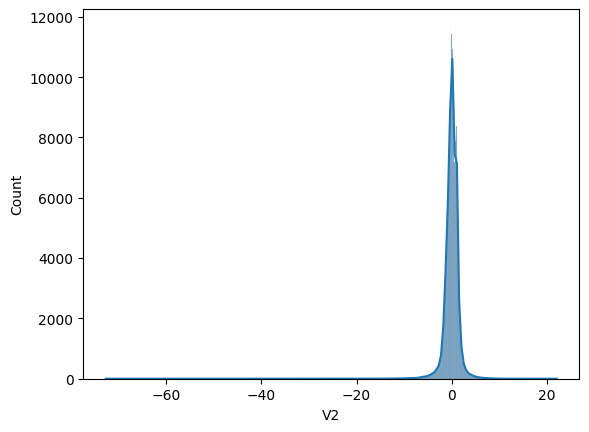

In [11]:
sns.histplot(df['V2'], kde = True)

<Axes: xlabel='Time', ylabel='Count'>

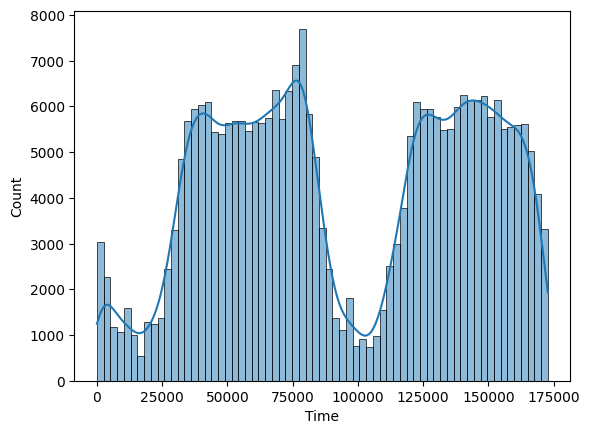

In [12]:
sns.histplot(df['Time'], kde = True)

<Axes: xlabel='Amount', ylabel='Count'>

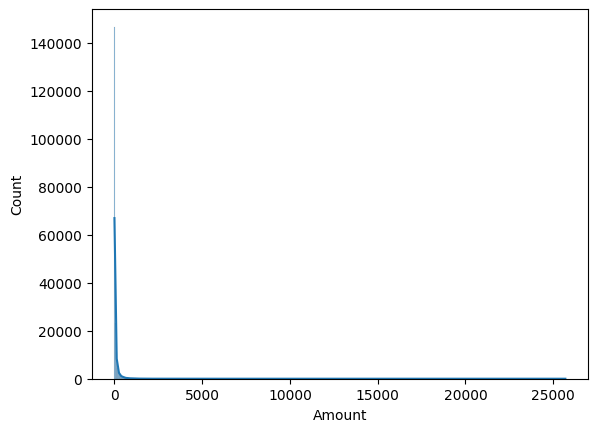

In [13]:
sns.histplot(df['Amount'], kde = True)

### 1.1 Handling Skewness in `Amount`

The `Amount` column is heavily right-skewed (most transactions are small, a few are very large).
We apply a **log1p transform** to compress the scale and reduce skewness before feeding it to the model.
`log1p(x) = log(1 + x)` handles zero values safely.

In [14]:
# log transform of Amount column
df['Amount_log'] = np.log1p(df['Amount'])

In [15]:
df['Amount_log'].skew()

np.float64(0.16270292774164008)

<Axes: xlabel='Amount_log', ylabel='Count'>

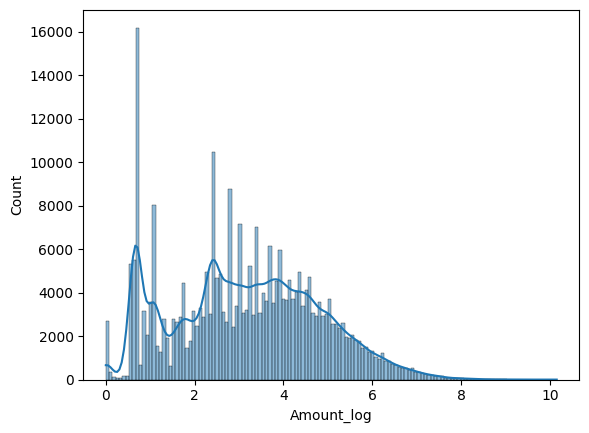

In [16]:
sns.histplot(df['Amount_log'], kde = True)

## 2. Preprocessing

### 2.1 Feature-Target Split and Dropping Raw `Amount`

We separate features (`X`) from the target (`y`), then drop the original `Amount` column
since we've replaced it with `Amount_log`.

In [17]:
X = df.drop(columns = ['Class'])
y = df['Class']

In [18]:
y.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [19]:
X.drop(columns = ['Amount'], inplace = True)

### 2.2 Train-Test Split

We split the data 80/20 with `stratify=y` to ensure both sets preserve the original
fraud ratio (~0.17%). Without stratification, the test set could accidentally contain
very few or zero fraud cases, making evaluation meaningless.

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify =y)

### 2.3 Scaling `Amount_log` with RobustScaler

We scale `Amount_log` using `RobustScaler` instead of `StandardScaler`.
`RobustScaler` uses the **median and IQR** rather than mean and std, making it
resistant to outliers. In fraud data, extreme transaction amounts are the signal —
we don't want the scaler to be distorted by them.

**Critical rule:** We `fit` only on training data and `transform` both train and test.
Fitting on the full dataset would leak test distribution into training — a form of data leakage.

In [21]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train['Amount_log'] = scaler.fit_transform(X_train[['Amount_log']])
X_test['Amount_log'] = scaler.transform(X_test[['Amount_log']])

<Axes: xlabel='Amount_log', ylabel='Count'>

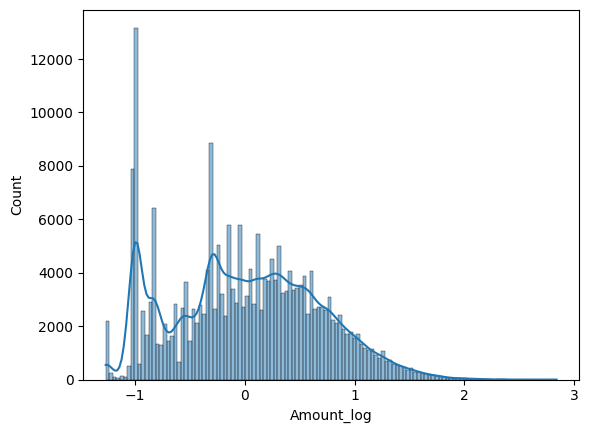

In [22]:
sns.histplot(x = X_train['Amount_log'], kde = True)

In [23]:
print(X_train['Amount_log'].skew())

0.1603927115829192


### 2.4 Cyclical Encoding of Transaction Hour

The `Time` column is seconds elapsed since the first transaction. We convert it to
hour-of-day (0–23) and then apply **trigonometric (cyclical) encoding**.

Why not just use the hour number directly? Because hour 23 and hour 0 are only
1 hour apart, but numerically they're 23 apart. A linear feature would mislead the model.
Encoding as `sin` and `cos` preserves this circular continuity — `Hour_Sin` and `Hour_Cos`
together represent any hour on a circle.

In [24]:
X_train['Hour'] = (X_train['Time'] / 3600) % 24
X_test['Hour'] = (X_test['Time'] / 3600) % 24

In [25]:
X_train

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log,Hour
265518,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.411696,20.977500
180305,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-0.709232,10.576944
42664,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,0.824159,11.441944
198723,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.475897,12.840000
82325,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,0.539125,16.488611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233802,147710.0,1.993864,-0.516866,-0.620118,0.129845,-0.285128,0.395044,-0.822358,0.231591,0.995898,...,0.262526,0.884510,0.099141,0.275689,-0.195404,0.623598,-0.032455,-0.058552,-0.482219,17.030556
85418,60764.0,-1.497933,0.657921,1.581568,-0.024286,0.584698,1.303031,0.609212,0.135561,0.452745,...,-0.072452,0.299172,0.110048,-0.615980,-0.425883,0.263968,-0.448445,0.045178,0.203181,16.878889
29062,35301.0,1.069777,0.072105,0.496540,1.505318,-0.380277,-0.370243,0.100551,-0.026687,0.319684,...,-0.061991,-0.044629,-0.050485,0.400171,0.593314,-0.335160,0.031014,0.024886,0.284322,9.805833
13766,24413.0,1.280465,0.300586,0.333044,0.512720,0.065052,-0.145844,-0.145519,-0.091833,1.111187,...,-0.409934,-0.961351,0.033153,-0.560429,0.278428,0.089546,-0.059835,-0.005887,-1.011765,6.781389


In [26]:
# Cyclical Trigonometric Free
train_hours_in_radians = (2 * np.pi * X_train['Hour']) / 24
test_hours_in_radians = (2 * np.pi * X_test['Hour']) / 24

In [27]:
X_train['Hour_Sin'] = np.sin(train_hours_in_radians)
X_train['Hour_Cos'] = np.cos(train_hours_in_radians)

In [28]:
X_test['Hour_Sin'] = np.sin(test_hours_in_radians)
X_test['Hour_Cos'] = np.cos(test_hours_in_radians)

In [29]:
X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount_log,Hour,Hour_Sin,Hour_Cos
265518,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.411696,20.977500,-0.711260,0.702929
180305,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-0.709232,10.576944,0.363996,-0.931400
42664,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,0.824159,11.441944,0.145579,-0.989347
198723,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.475897,12.840000,-0.218143,-0.975917
82325,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,0.539125,16.488611,-0.922734,-0.385436


In [30]:
X_train.drop(columns = ['Time', 'Hour'], inplace = True)
X_test.drop(columns = ['Time', 'Hour'], inplace = True)

In [31]:
X_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount_log,Hour_Sin,Hour_Cos
265518,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,...,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.411696,-0.711260,0.702929
180305,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,...,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-0.709232,0.363996,-0.931400
42664,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,...,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,0.824159,0.145579,-0.989347
198723,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,...,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.475897,-0.218143,-0.975917
82325,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,...,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,0.539125,-0.922734,-0.385436


## 3. Handling Class Imbalance

The dataset has a severe imbalance: ~284,000 legitimate transactions vs. ~492 fraudulent ones.
A naive model that predicts "Legitimate" every time would achieve 99.83% accuracy —
yet be completely useless.

We compute `fraud_weight` as the ratio of legitimate to fraud cases and pass it to XGBoost
via `scale_pos_weight`. This forces the model to penalize missing a fraud case
proportionally more than missing a legitimate one during training.

In [32]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

### Calculating Fraud weight to use it later for XGBoost model

In [33]:
# Calculate the total 0s divided by total 1s
fraud_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [34]:
fraud_weight

np.float64(577.2868020304569)

## 4. Model Training and Evaluation

We train three types of models and compare them systematically:
- **Logistic Regression** — linear baseline, fast and interpretable
- **Random Forest** — ensemble of decision trees, strong on tabular data
- **XGBoost (Base)** — gradient boosted trees, no imbalance handling
- **XGBoost (Balanced)** — same, with `scale_pos_weight` to handle class imbalance

The primary evaluation metric is **PR-AUC (Precision-Recall AUC)**, not accuracy.
On imbalanced datasets, accuracy is misleading. PR-AUC measures how well the model
ranks fraud cases across all possible thresholds — a far more honest measure.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [36]:
from sklearn.metrics import confusion_matrix, classification_report

In [37]:
# General confusion matrix plot function
def plot_confusion_matrix(y_true, y_pred, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()

### 4.1 Logistic Regression (Baseline)

A simple, fast linear model with `class_weight='balanced'` to handle imbalance.
We use the `saga` solver which handles large datasets efficiently.
This establishes the baseline that tree-based models must beat.

In [38]:
test_model = LogisticRegression(max_iter = 1000, solver = 'saga', class_weight = 'balanced', random_state = 42)
test_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
test_y_pred = test_model.predict(X_test)

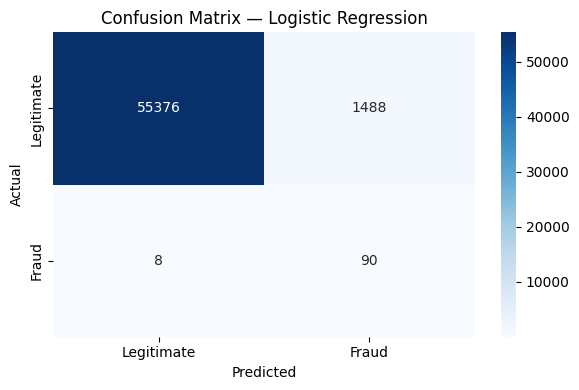

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [40]:
plot_confusion_matrix(y_test, test_y_pred, 'Logistic Regression')
print(classification_report(y_test, test_y_pred))

### 4.2 Random Forest

An ensemble of 100 decision trees. Each tree sees a random subset of data and features,
and the final prediction is a majority vote. `class_weight='balanced'` applies inverse
class frequency as sample weights during training.

In [41]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
y_pred_rf = rf_model.predict(X_test)

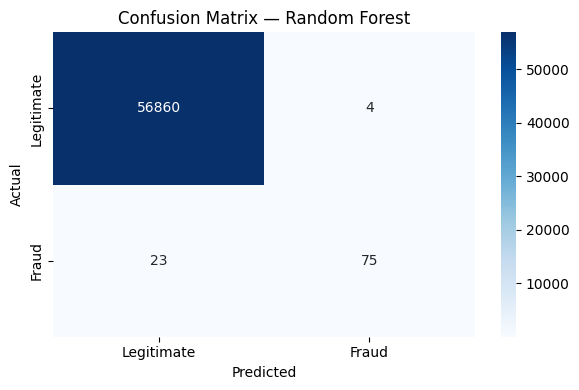

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.77      0.85        98

    accuracy                           1.00     56962
   macro avg       0.97      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [43]:
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')
print(classification_report(y_test, y_pred_rf))

### 4.3 XGBoost — Base Model (No Imbalance Handling)

We train a baseline XGBoost with all default parameters and no imbalance correction.
This intentionally shows what happens when you ignore the skewed class distribution —
high precision but very low recall, missing most actual frauds.

In [44]:
# Baseline Model
base_model = XGBClassifier(random_state = 42)

In [45]:
base_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [46]:
y_pred_xgb_base = base_model.predict(X_test)

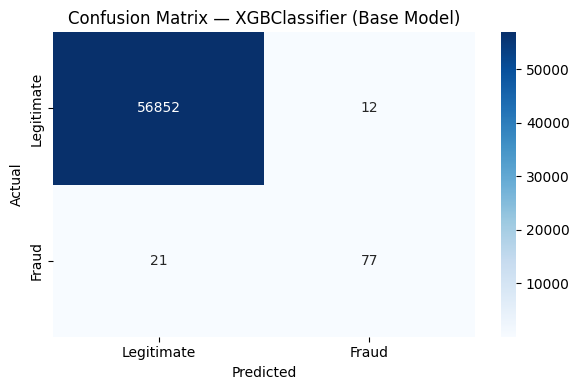

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.79      0.82        98

    accuracy                           1.00     56962
   macro avg       0.93      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [47]:
plot_confusion_matrix(y_test, y_pred_xgb_base, 'XGBClassifier (Base Model)')
print(classification_report(y_test, y_pred_xgb_base))

### 4.4 XGBoost — Balanced Model (scale_pos_weight)

`scale_pos_weight` tells XGBoost's loss function to weight each fraud misclassification
by the ratio of legitimate to fraud samples (~577x here). This is the algorithmic
approach to imbalance — the data distribution stays the same, but the model learns
to care significantly more about getting fraud cases right.

In [48]:
# Using scale_pos_weight
balanced_model = XGBClassifier(random_state = 42, scale_pos_weight = fraud_weight)
balanced_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [49]:
y_pred_xgb_bal = balanced_model.predict(X_test)

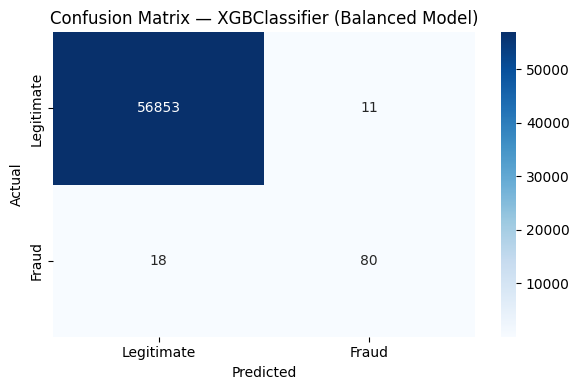

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.82      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [50]:
plot_confusion_matrix(y_test, y_pred_xgb_bal, 'XGBClassifier (Balanced Model)')
print(classification_report(y_test, y_pred_xgb_bal))

In [51]:
from sklearn.metrics import average_precision_score

# Compute PR-AUC for all models
models_summary = {
    'Logistic Regression': test_model,
    'Random Forest': rf_model,
    'XGBoost Base': base_model,
    'XGBoost Balanced': balanced_model
}

print("=" * 45)
print(f"{'Model':<25} {'PR-AUC':>10}")
print("=" * 45)
for name, model in models_summary.items():
    prob = model.predict_proba(X_test)[:, 1]
    score = average_precision_score(y_test, prob)
    print(f"{name:<25} {score:>10.4f}")
print("=" * 45)

Model                         PR-AUC
Logistic Regression           0.7116
Random Forest                 0.8639
XGBoost Base                  0.7897
XGBoost Balanced              0.8793


## 5. Feature Importance

We inspect which features drive the XGBoost model's fraud predictions.
This is a sanity check — if `Amount_log` or `Hour_Sin` appear at the top,
it suggests the engineered features added meaningful signal.
XGBoost feature importance is measured by how often a feature is used in tree splits
and by how much it reduces the loss.

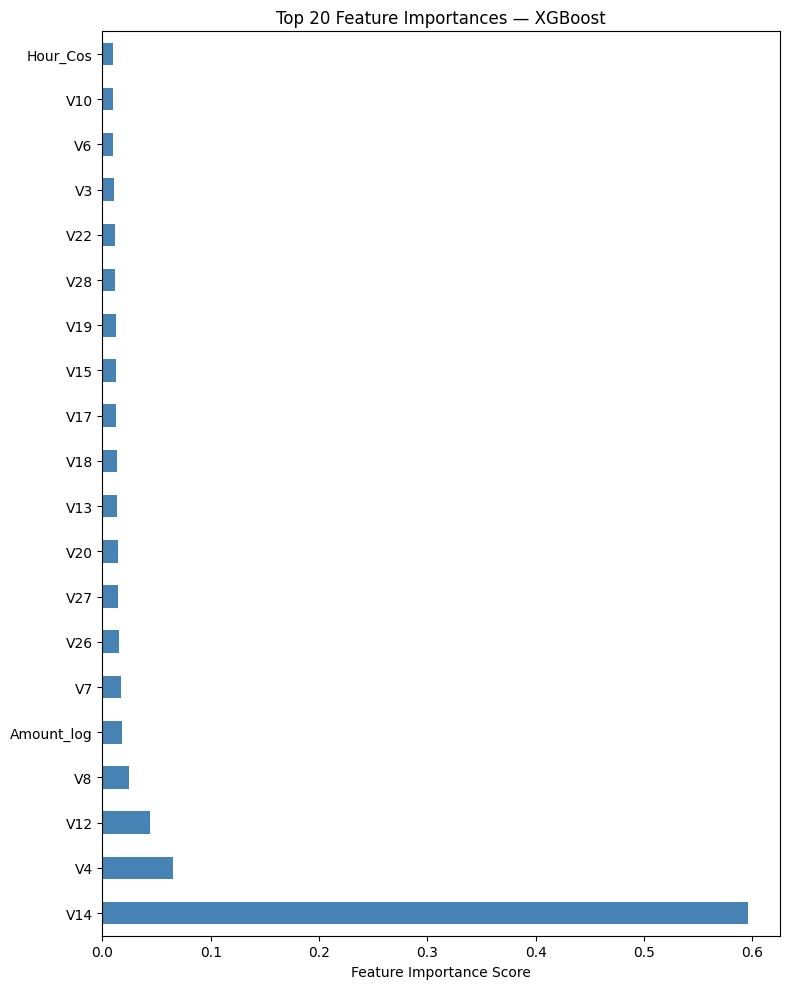

In [52]:
# Note: We retain all 31 features for the production model.
# Feature selection was not applied because:
# 1. 31 features is computationally trivial for XGBoost
# 2. V1-V28 are already PCA-compressed — further reduction risks information loss
# 3. Dropping low-importance features showed no PR-AUC improvement in exploratory tests
# The importance plot serves as interpretability insight, not a selection filter.

feat_imp = pd.Series(
    balanced_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 10))
feat_imp.nlargest(20).plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Feature Importances — XGBoost')
plt.tight_layout()
plt.show()

## 6. Cross-Validation

A single 80/20 train-test split can be misleading — results may be specific to
that random partition. We use **5-fold Stratified Cross-Validation** on the training
data to measure model stability.

Each fold maintains the original fraud ratio. The mean ± std of PR-AUC across folds
tells us whether the model generalizes consistently or is unstable.
Note: We validate on `X_train` only. The test set remains a completely untouched final holdout.

In [53]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

cv_pr_auc = cross_val_score(
    balanced_model,
    X_train,
    y_train,
    cv = cv,
    scoring = 'average_precision',
    n_jobs = -1
)

print(f'PR_AUC across 5-folds: {cv_pr_auc}')
print(f'Mean PR_AUC: {cv_pr_auc.mean():.4f} ± {cv_pr_auc.std():.4f}')

PR_AUC across 5-folds: [0.86146668 0.82191555 0.81920037 0.88095738 0.85490996]
Mean PR_AUC: 0.8477 ± 0.0238


## 7. Final Model Evaluation on Holdout Test Set

With the model validated via cross-validation, we now run a full evaluation on the
held-out test set. We compute two curves:

- **ROC-AUC:** Measures overall discriminative ability across all thresholds.
  Useful but can be optimistic on imbalanced data.
- **PR-AUC (Average Precision):** Focuses specifically on the minority (fraud) class.
  This is the primary metric — a high PR-AUC means the model reliably ranks
  true frauds above legitimate transactions.

In [54]:
y_prob = balanced_model.predict_proba(X_test)[:, 1]

In [55]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9695


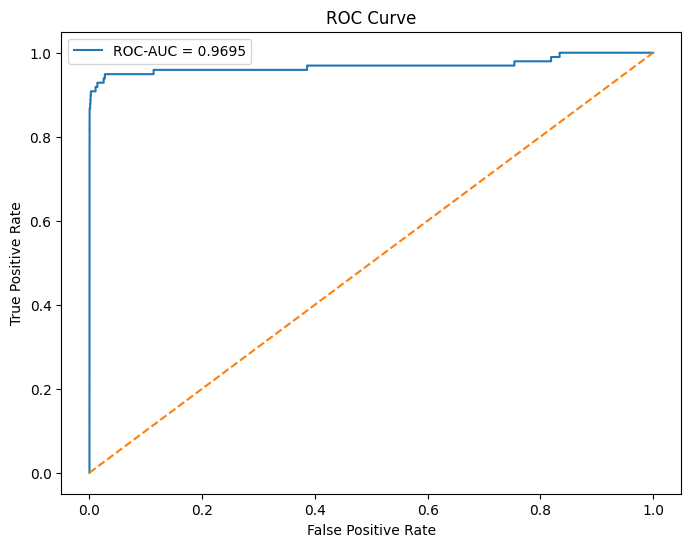

In [56]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [57]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)

print(f"PR-AUC Score: {pr_auc:.4f}")

PR-AUC Score: 0.8793


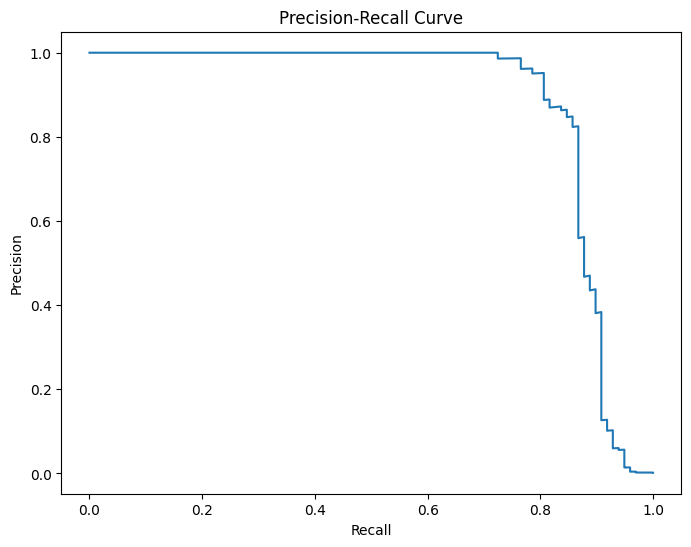

In [58]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test,y_prob)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## 8. Imbalance Strategy Comparison — scale_pos_weight vs. SMOTE-Tomek

We compare two fundamentally different approaches to handling class imbalance:

**Approach A (already trained):** `scale_pos_weight` — algorithmic correction.
The model sees skewed data but penalizes fraud misclassification more heavily.

**Approach B (this section):** SMOTE-Tomek — data-level resampling.
- **SMOTE** synthesizes new fraud samples by interpolating between existing ones in feature space.
- **Tomek Links** removes majority-class samples that sit too close to the decision boundary, sharpening it.

Running SMOTE on 284k rows is computationally infeasible on a local machine (O(n²) neighbor search).
We run this experiment on a **stratified 20% subsample** of training data to make it tractable,
then compare PR-AUC scores. The result isolates the effect of resampling strategy,
though the scale_pos_weight model benefits from training on more data overall.

In [59]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split

# Take a stratified 20% sample of training data for the experiment
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train,
    test_size=0.8,
    stratify=y_train,
    random_state=42
)

print(f"Sample size: {len(X_sample)}, Fraud cases: {y_sample.sum()}")

# Apply SMOTE-Tomek on the sample
smt = SMOTETomek(random_state=42)
X_resampled, y_resampled = smt.fit_resample(X_sample, y_sample)

print(f"After resampling: {len(X_resampled)}, Fraud: {y_resampled.sum()}, Legit: {(y_resampled==0).sum()}")

Sample size: 45569, Fraud cases: 79
After resampling: 90980, Fraud: 45490, Legit: 45490


In [60]:
smote_model = XGBClassifier(random_state=42)
smote_model.fit(X_resampled, y_resampled)

y_prob_smote = smote_model.predict_proba(X_test)[:, 1]
pr_auc_smote = average_precision_score(y_test, y_prob_smote)
pr_auc_baseline = average_precision_score(y_test, y_prob)  # from your existing balanced_model

print(f"PR-AUC (scale_pos_weight, full data): {pr_auc_baseline:.4f}")
print(f"PR-AUC (SMOTE-Tomek, 20% sample): {pr_auc_smote:.4f}")

PR-AUC (scale_pos_weight, full data): 0.8793
PR-AUC (SMOTE-Tomek, 20% sample): 0.8462


## 9. Decision Threshold Tuning

XGBoost outputs a **fraud probability score** between 0 and 1.
The default decision threshold of 0.5 (predict fraud if score ≥ 0.5) is arbitrary
and wrong for fraud detection.

We sweep thresholds from 0.1 to 0.5 and measure Precision, Recall, and F1.
The business logic: **Recall is the priority** (we must catch real frauds),
but Precision must stay above a minimum floor (say 40%) to avoid overwhelming
analysts with false alarms.

We select the threshold that **maximizes Recall with Precision ≥ 0.40**.
This chosen threshold is saved as `optimal_threshold` and will be used by the
production API in Phase 2.

In [61]:
# Threshold Tuning
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

pd.DataFrame(results)

,Threshold,Precision,Recall,F1
0,0.1,0.794393,0.867347,0.829268
1,0.2,0.855670,0.846939,0.851282
2,0.3,0.864583,0.846939,0.855670
3,0.4,0.879121,0.816327,0.846561
4,0.5,0.879121,0.816327,0.846561


In [62]:
results_df = pd.DataFrame(results)

# In fraud detection, recall is king — we want to catch as many frauds as possible.
# But we need precision to stay above a business-acceptable floor (e.g., 40%),
# otherwise legitimate customers get flagged too often and we lose trust.

# Strategy: maximize Recall where Precision >= 0.40
acceptable = results_df[results_df['Precision'] >= 0.40]
best_row = acceptable.loc[acceptable['Recall'].idxmax()]

print(f"Selected Threshold: {best_row['Threshold']}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"F1: {best_row['F1']:.4f}")

optimal_threshold = best_row['Threshold']

Selected Threshold: 0.1
Precision: 0.7944
Recall: 0.8673
F1: 0.8293


## 10. Saving Model Artifacts

We save three artifacts to the `../models/` directory:
- `xgb_fraud_model.pkl` — the trained XGBoost model
- `robust_scaler.pkl` — the fitted scaler (must be the same one used during training)
- `config.json` — the optimal decision threshold

The scaler and threshold are saved separately because the FastAPI serving layer needs
all three to reproduce the exact same prediction pipeline. Hardcoding the threshold
in the API would be bad practice — loading it from config means it can be updated
without touching serving code.

In [63]:
import joblib
import json
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the trained XGBoost model
joblib.dump(balanced_model, '../models/xgb_fraud_model.pkl')

# Save the fitted scaler
joblib.dump(scaler, '../models/robust_scaler.pkl')

# Save the optimal threshold as a config file
with open('../models/config.json', 'w') as f:
    json.dump({'optimal_threshold': float(optimal_threshold)}, f, indent=2)

print("✓ Model saved     → ../models/xgb_fraud_model.pkl")
print("✓ Scaler saved    → ../models/robust_scaler.pkl")
print("✓ Config saved    → ../models/config.json")

feature_columns = X_train.columns.tolist()
with open('../models/feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

print(feature_columns)

✓ Model saved     → ../models/xgb_fraud_model.pkl
✓ Scaler saved    → ../models/robust_scaler.pkl
✓ Config saved    → ../models/config.json
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log', 'Hour_Sin', 'Hour_Cos']


In [64]:
import json
# Save 50 random test transactions as JSON for API testing
sample = X_test.copy()
sample['Amount_original'] = df.loc[X_test.index, 'Amount']
sample['Hour'] = (df.loc[X_test.index, 'Time'] // 3600 % 24).astype(int)
sample['Class'] = y_test

# Choosing 25 legitimate and 25 fraud transaction
legit_samples = sample[sample['Class'] == 0].sample(48, random_state=42)
fraud_samples = sample[sample['Class'] == 1].sample(2, random_state=42)
test_samples = pd.concat([legit_samples, fraud_samples])

transactions = []
for idx, row in test_samples.iterrows():
    t = {'transaction_id': str(idx)}
    for v in [f'V{i}' for i in range(1, 29)]:
        t[v] = round(float(row[v]), 6)
    t['Amount'] = round(float(row['Amount_original']), 2)
    t['Hour'] = int(row['Hour'])
    transactions.append(t)

with open('../models/sample_transactions.json', 'w') as f:
    json.dump(transactions, f, indent = 2)

print(f'Saved {len(transactions)} sample transactions')
print(f'Fraud cases: {sum(1 for t in transactions if test_samples.loc[int(t['transaction_id']), 'Class'] == 1)}')

Saved 50 sample transactions
Fraud cases: 2


In [65]:
import json
import numpy as np

# Save training data statistics as reference distribution for drift monitoring
reference_stats = {}

for col in X_train.columns:
    reference_stats[col] = {
        'mean': float(X_train[col].mean()),
        'std': float(X_train[col].std()),
        'min': float(X_train[col].min()),
        'max': float(X_train[col].max()),
        'percentiles': {
            '10': float(np.percentile(X_train[col], 10)),
            '25': float(np.percentile(X_train[col], 25)),
            '50': float(np.percentile(X_train[col], 50)),
            '75': float(np.percentile(X_train[col], 75)),
            '90': float(np.percentile(X_train[col], 90))
        }
    }

with open('../models/reference_stats.json', 'w') as f:
    json.dump(reference_stats, f, indent=2)

# Also save the actual training data sample for KS test
# We save a 10% stratified sample to keep file size manageable
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train,
    test_size=0.9,
    stratify=y_train,
    random_state=42
)

X_train_sample.to_csv('../models/reference_sample.csv', index=False)

print(f"Reference stats saved for {len(reference_stats)} features")
print(f"Reference sample saved: {len(X_train_sample)} rows")

Reference stats saved for 31 features
Reference sample saved: 22784 rows


In [69]:
# Generate synthetic transactions from training distributions
def generate_synthetic_transaction():
    synthetic = {}
    for col in [f'V{i}' for i in range(1, 29)]:
        mean = float(X_train[col].mean())
        std = float(X_train[col].std())
        synthetic[col] = round(float(np.random.normal(mean, std)), 6)
    synthetic['Amount'] = round(float(min(np.random.exponential(scale=88), 5000)), 2)
    synthetic['Hour'] = int(np.random.randint(0, 24))
    synthetic['transaction_id'] = f"SYN-{np.random.randint(100000, 999999)}"
    return synthetic

In [70]:
def generate_fraud_pattern_transaction():
    t = generate_synthetic_transaction()
    t['V14'] = round(float(np.random.normal(-15, 1.5)), 6)
    t['V4']  = round(float(np.random.normal(-8, 1.5)), 6)
    t['V12'] = round(float(np.random.normal(-10, 1.5)), 6)
    t['V8']  = round(float(np.random.normal(-8, 1.5)), 6)
    t['V7']  = round(float(np.random.normal(-8, 1.5)), 6)  # V7 instead of V11
    t['Amount'] = round(float(np.random.uniform(1, 200)), 2)
    t['transaction_id'] = f"SYN-{np.random.randint(100000, 999999)}"
    return t

In [71]:
import random
np.random.seed(42)
synthetic_transactions = []

for _ in range(80):
    synthetic_transactions.append(generate_synthetic_transaction())
for _ in range(20):
    synthetic_transactions.append(generate_fraud_pattern_transaction())

random.shuffle(synthetic_transactions)

with open('../models/sample_transactions.json', 'w') as f:
    json.dump(synthetic_transactions, f, indent=2)

print(f"✓ Generated {len(synthetic_transactions)} synthetic transactions")
print(f"  Legitimate-pattern : 80")
print(f"  Fraud-pattern      : 20")

✓ Generated 100 synthetic transactions
  Legitimate-pattern : 80
  Fraud-pattern      : 20
